In [31]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
# Seasonality
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np


In [32]:
df = pd.read_csv('../intro_to_time_series/weekly_customer_complaints.csv', parse_dates=True, index_col='week')
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   complaints               261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


Data- preprocessing

In [34]:
# Remove comma and transform to float
df['complaints']=df['complaints'].str.replace(',', '').astype(float)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750.0,37.26%,1,0,0
2018-01-08,1701.0,35.38%,0,0,0
2018-01-15,1711.0,36.22%,1,0,0
2018-01-22,1443.0,38.33%,1,0,0
2018-01-29,1397.0,36.34%,0,0,0


In [35]:
# setting freq to W implies that the week starts on Sunday
df = df.asfreq('W-Mon')  
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

Exploratory data analysis

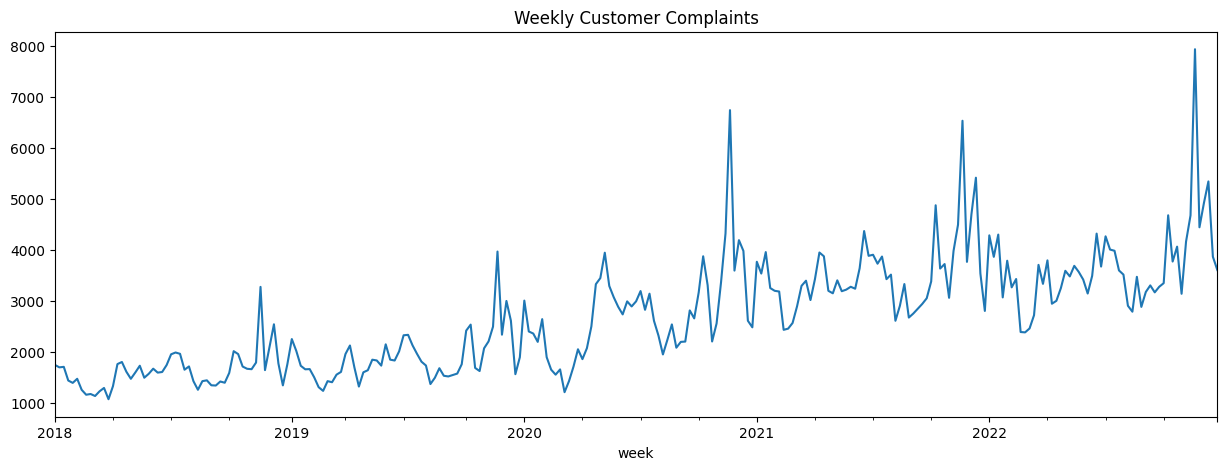

In [36]:
df['complaints'].plot(figsize=(15, 5))
plt.title('Weekly Customer Complaints')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_29080\2104844781.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['complaints'].resample('M').mean(),


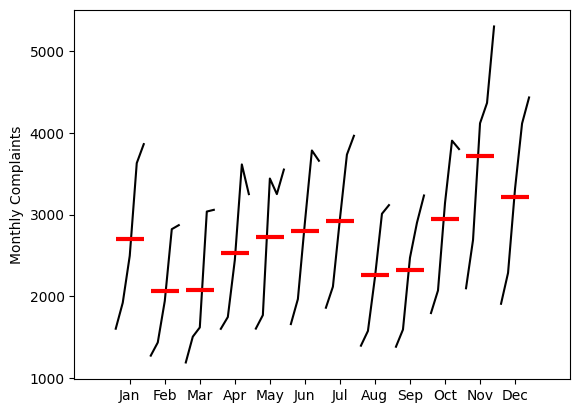

In [37]:
# Plotting the monthly seasonality
month_plot(df['complaints'].resample('M').mean(),
           ylabel='Monthly Complaints')
plt.show()   


C:\Users\msi\AppData\Local\Temp\ipykernel_29080\2996227978.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['complaints'].resample('Q').mean(),


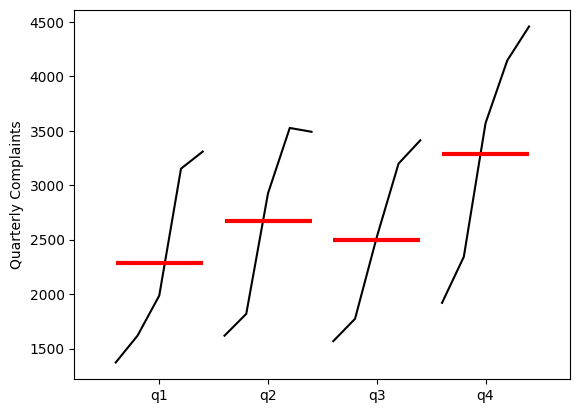

In [38]:
# Plotting the quarterly seasonality
quarter_plot(df['complaints'].resample('Q').mean(),
                ylabel='Quarterly Complaints')
plt.show()

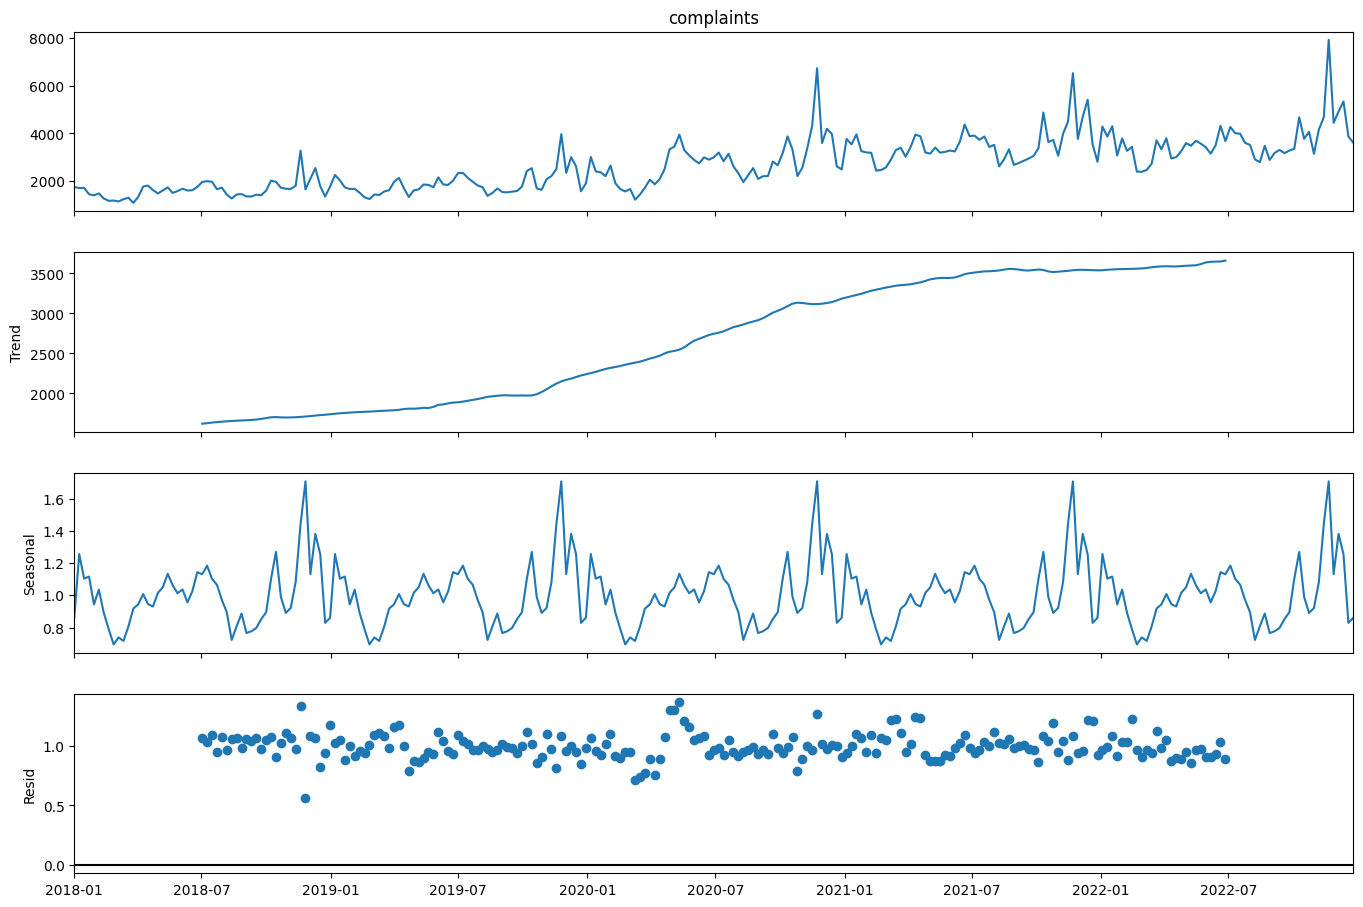

In [39]:
# Seasonal decomposition
decompostion = seasonal_decompose(df['complaints'], model='multiplicative', period=52)
fig = decompostion.plot()
fig.set_size_inches(15, 10) 
plt.show()

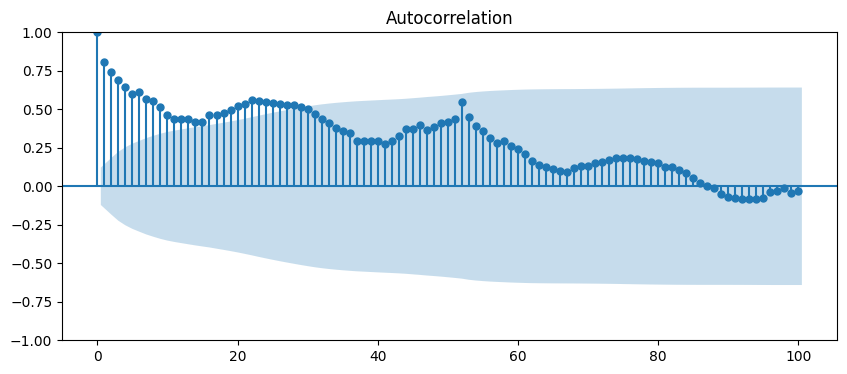

In [40]:
# Plot the autocorrelation 
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df['complaints'], lags=100, ax=ax)
plt.show()

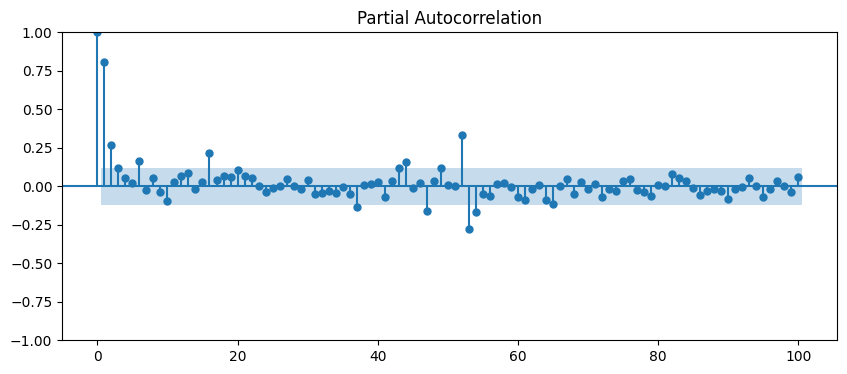

In [41]:
# Plot the partial autocorrelation

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(df['complaints'], lags=100, ax=ax)
plt.show()

# Training and test

 Goal: to predict the nedxt quarter( 13 weeks)

In [42]:
# Training and test split
periods = 13
train, test = df.iloc[:-periods,0], df.iloc[-periods:, 0 ]
test.head()

week
2022-10-03    3350.0
2022-10-10    4679.0
2022-10-17    3773.0
2022-10-24    4065.0
2022-10-31    3142.0
Freq: W-MON, Name: complaints, dtype: float64

In [43]:
test

week
2022-10-03    3350.0
2022-10-10    4679.0
2022-10-17    3773.0
2022-10-24    4065.0
2022-10-31    3142.0
2022-11-07    4164.0
2022-11-14    4677.0
2022-11-21    7931.0
2022-11-28    4444.0
2022-12-05    4920.0
2022-12-12    5342.0
2022-12-19    3868.0
2022-12-26    3607.0
Freq: W-MON, Name: complaints, dtype: float64

Simple Exponential Smoothings

In [44]:
# Simple Exponential Smoothing model and Prediction
model_simple = SimpleExpSmoothing(train).fit()
model_simple.forecast(len(test))

2022-10-03    3236.663473
2022-10-10    3236.663473
2022-10-17    3236.663473
2022-10-24    3236.663473
2022-10-31    3236.663473
2022-11-07    3236.663473
2022-11-14    3236.663473
2022-11-21    3236.663473
2022-11-28    3236.663473
2022-12-05    3236.663473
2022-12-12    3236.663473
2022-12-19    3236.663473
2022-12-26    3236.663473
Freq: W-MON, dtype: float64

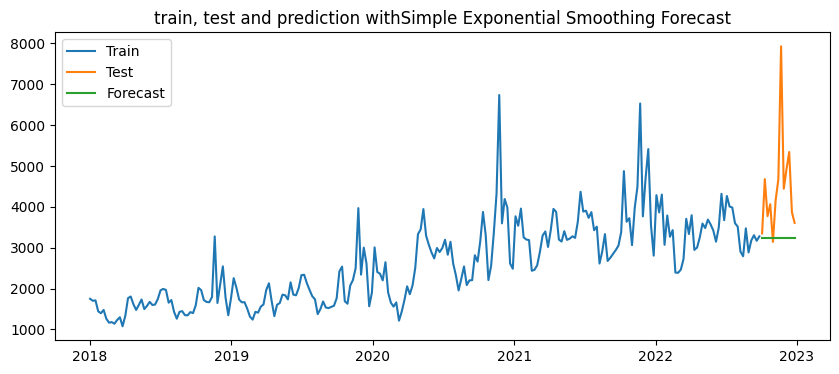

In [45]:
# Plot training, test and forecasts
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(model_simple.forecast(len(test)), label='Forecast')
plt.title('train, test and prediction withSimple Exponential Smoothing Forecast')
plt.legend()
plt.show()

# Double Exponential smoothing

In [46]:
# Double Exponential Smoothing model 
model_double = ExponentialSmoothing(train, trend='add', seasonal = None).fit()

In [47]:
# Prediction
prediction_double = model_double.forecast(len(test))
prediction_double

2022-10-03    3248.188426
2022-10-10    3254.078922
2022-10-17    3259.969417
2022-10-24    3265.859912
2022-10-31    3271.750408
2022-11-07    3277.640903
2022-11-14    3283.531399
2022-11-21    3289.421894
2022-11-28    3295.312389
2022-12-05    3301.202885
2022-12-12    3307.093380
2022-12-19    3312.983876
2022-12-26    3318.874371
Freq: W-MON, dtype: float64

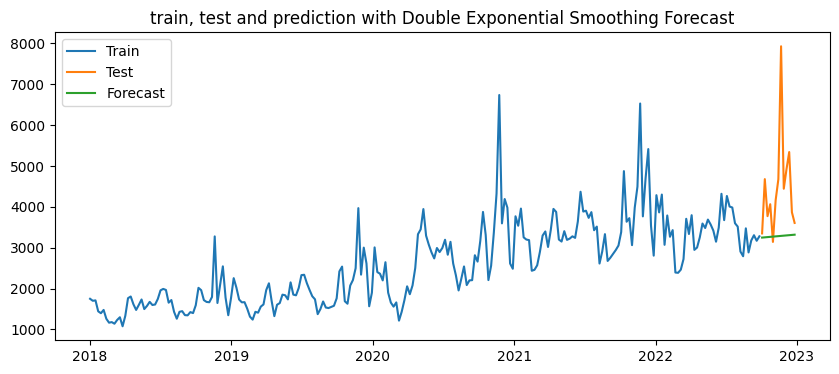

In [48]:
# Plot training, test and forecasts
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(prediction_double, label='Forecast')
plt.title('train, test and prediction with Double Exponential Smoothing Forecast')
plt.legend()
plt.show()

# Triple exponential smoothing
(Holt-Winters method)

In [49]:
# Triple Exponential Smoothing model 
model_triple = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=52).fit()

In [50]:
# Prediction
prediction_triple = model_triple.forecast(len(test))
prediction_triple

2022-10-03    4041.111424
2022-10-10    5040.624784
2022-10-17    3931.859447
2022-10-24    3531.087941
2022-10-31    3441.012595
2022-11-07    4260.019517
2022-11-14    5352.531269
2022-11-21    7237.950721
2022-11-28    4358.900107
2022-12-05    5316.382668
2022-12-12    5271.229643
2022-12-19    3471.734921
2022-12-26    3336.466558
Freq: W-MON, dtype: float64

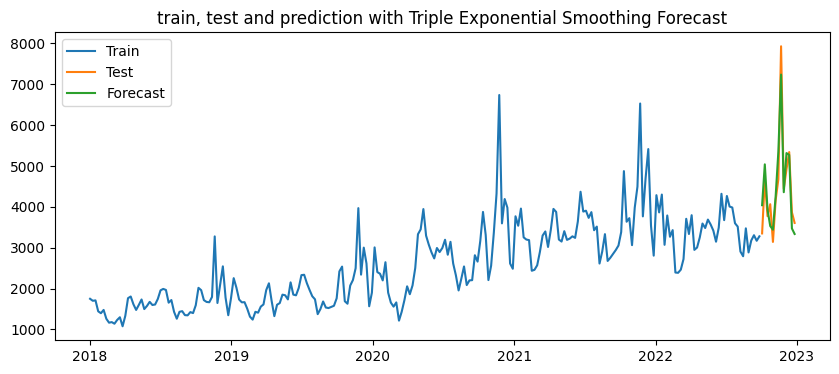

In [51]:
# Plot training, test and forecasts
plt.figure(figsize=(10, 4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(prediction_triple, label='Forecast')
plt.title('train, test and prediction with Triple Exponential Smoothing Forecast')
plt.legend()
plt.show()

MAE tells you average complaint difference

RMSE tells you if you made any large bad predictions

MAPE tells you business-friendly accuracy %

In [52]:
# Calulate the MAE, MAPE and RMSE 
mae = mean_absolute_error(test, prediction_triple)
mse = mean_squared_error(test, prediction_triple)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, prediction_triple)
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape*100:.2f}%')

MAE: 363.70552405754313
RMSE: 425.49319656000307
MAPE: 8.44%


MAE: 363.70552405754313
RMSE: 425.49319656000307
MAPE: 8.44%


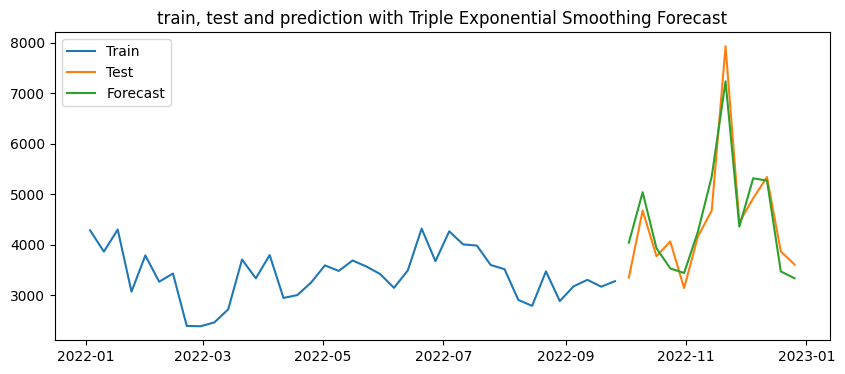

In [53]:
# function to asses model and visualize the output
def model_assessment(train, test, predictions, chart_title):
    mae = mean_absolute_error(test, predictions)
    mse = mean_squared_error(test, predictions)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(test, predictions)
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MAPE: {mape*100:.2f}%')
    
    plt.figure(figsize=(10, 4))
    plt.plot(train, label='Train')
    plt.plot(test, label='Test')
    plt.plot(predictions, label='Forecast')
    plt.title(chart_title)
    plt.legend()
    plt.show()
model_assessment(train['2022':], test, prediction_triple, 'train, test and prediction with Triple Exponential Smoothing Forecast')

The Holt-Winters model captures the overall trend and seasonal pattern effectively, with reasonable error metrics. However, it slightly underreacts to sudden spikes, which suggests that extreme events are not fully captured by exponential smoothing.

Predict the Future

In [54]:
# Triple Exponential Smoothing model 
# To predict the future, include the whole data as  training data
model = ExponentialSmoothing(df.complaints, trend='add', seasonal='mul', seasonal_periods=52).fit()

In [55]:
# Prediction
forecast = model.forecast(13)
forecast

2023-01-02    4965.823628
2023-01-09    4478.079585
2023-01-16    4699.503400
2023-01-23    3814.113865
2023-01-30    4242.016324
2023-02-06    3726.289103
2023-02-13    3385.536420
2023-02-20    2879.470405
2023-02-27    2978.595984
2023-03-06    3044.215856
2023-03-13    3430.500524
2023-03-20    3923.832723
2023-03-27    3794.570270
Freq: W-MON, dtype: float64

In [56]:
# Function to plot the future forecast 
def plot_future(y,forecast,title):    
# Plot training, test and forecasts
    plt.figure(figsize=(10, 4))
    plt.plot(y, label='Train')

    plt.plot(forecast, label='Forecast')
    plt.title(f"Train and forecast with {title}")
    plt.legend()
    plt.show()

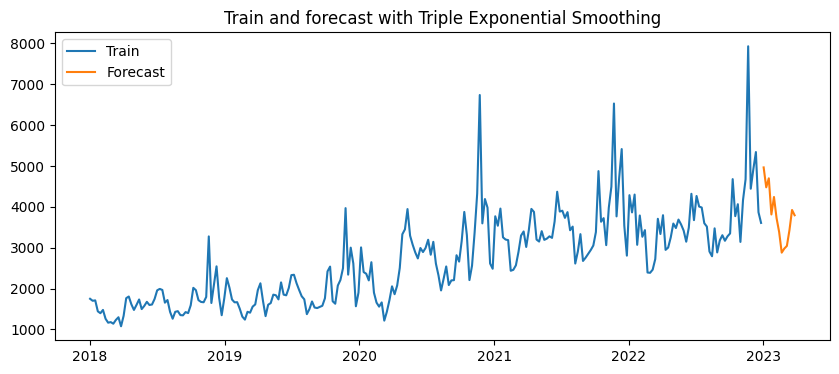

In [57]:
plot_future(df.complaints, forecast, 'Triple Exponential Smoothing')